In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import statsmodels.graphics.tsaplots as tsaplots
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

In [2]:
# Load the Excel file into a DataFrame
df = pd.read_excel('London_AQI_Daily.xlsx')
df['Date'] = pd.to_datetime(df['Date'], format='%Y-%m-%d')
# Display the first few rows of the DataFrame
df.head()
# test

,Date,USAQI
0,2013-01-02,36
1,2013-01-03,39
2,2013-01-04,34
3,2013-01-05,28
4,2013-01-06,38


In [3]:
df.describe()

,Date,USAQI
count,4441,4441.000000
mean,2019-01-31 00:00:00,47.441792
min,2013-01-02 00:00:00,17.000000
25%,2016-01-17 00:00:00,33.000000
50%,2019-01-31 00:00:00,43.000000
75%,2022-02-14 00:00:00,58.000000
max,2025-02-28 00:00:00,155.000000
std,NaN,19.187606


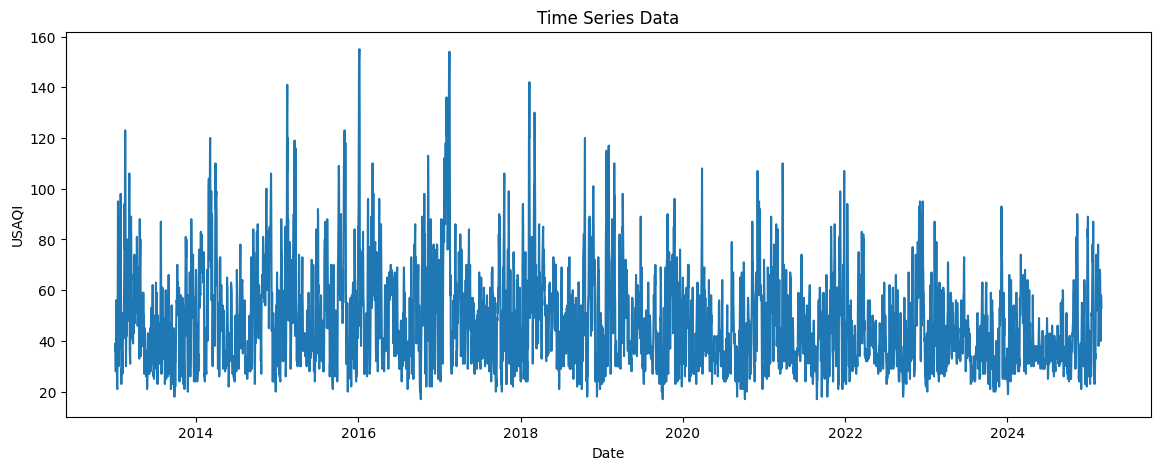

<Figure size 1400x500 with 0 Axes>

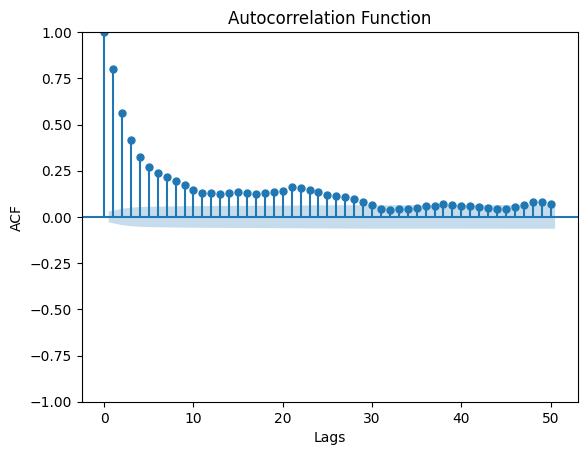

<Figure size 1400x500 with 0 Axes>

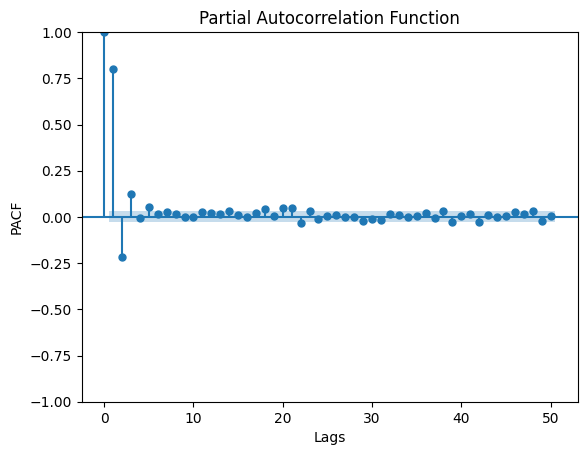

In [4]:

# Plot the time series data
plt.figure(figsize=(14, 5))
plt.plot(df['Date'], df['USAQI'])
plt.xlabel('Date')
plt.ylabel('USAQI')
plt.title('Time Series Data')
plt.show()

# Plot ACF
plt.figure(figsize=(14, 5))
tsaplots.plot_acf(df['USAQI'], lags=50)
plt.xlabel('Lags')
plt.ylabel('ACF')
plt.title('Autocorrelation Function')
plt.show()

# Plot PACF
plt.figure(figsize=(14, 5))
tsaplots.plot_pacf(df['USAQI'], lags=50)
plt.xlabel('Lags')
plt.ylabel('PACF')
plt.title('Partial Autocorrelation Function')
plt.show()

c:\Users\John\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


4230/4230 ━━━━━━━━━━━━━━━━━━━━ 59s 14ms/step - loss: 0.0127
133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


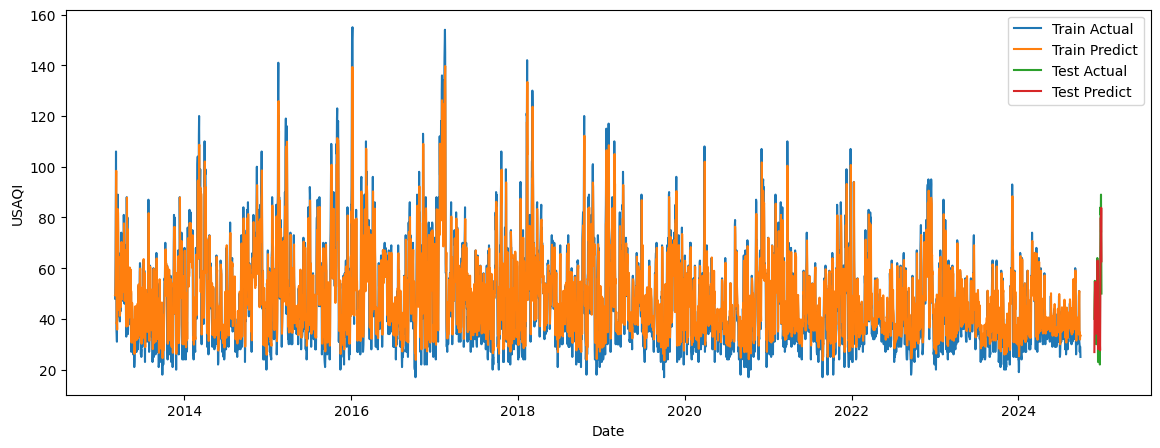

In [5]:

# Split the data into training and testing sets
train_df = df[(df['Date'] >= '2013-01-02') & (df['Date'] <= '2024-09-30')]
test_df = df[(df['Date'] >= '2024-10-01') & (df['Date'] <= '2024-12-31')]

# Normalize the data

scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train_df[['USAQI']])
test_scaled = scaler.transform(test_df[['USAQI']])

# Create sequences for LSTM
def create_sequences(data, seq_length):
    xs, ys = [], []
    for i in range(len(data) - seq_length):
        x = data[i:i+seq_length]
        y = data[i+seq_length]
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

seq_length = 60  # Sequence length
X_train, y_train = create_sequences(train_scaled, seq_length)
X_test, y_test = create_sequences(test_scaled, seq_length)

# Reshape input to be [samples, time steps, features]
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

# Build the LSTM model
model = Sequential()
model.add(LSTM(50, return_sequences=True, input_shape=(seq_length, 1)))
model.add(LSTM(50, return_sequences=False))
model.add(Dense(25))
model.add(Dense(1))

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
model.fit(X_train, y_train, batch_size=1, epochs=1)

# Make predictions
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

# Inverse transform the predictions
train_predict = scaler.inverse_transform(train_predict)
test_predict = scaler.inverse_transform(test_predict)

# Inverse transform the actual values
y_train = scaler.inverse_transform(y_train.reshape(-1, 1))
y_test = scaler.inverse_transform(y_test.reshape(-1, 1))

# Plot the results

plt.figure(figsize=(14, 5))
plt.plot(train_df['Date'][seq_length:], y_train, label='Train Actual')
plt.plot(train_df['Date'][seq_length:], train_predict, label='Train Predict')
plt.plot(test_df['Date'][seq_length:], y_test, label='Test Actual')
plt.plot(test_df['Date'][seq_length:], test_predict, label='Test Predict')
plt.xlabel('Date')
plt.ylabel('USAQI')
plt.legend()
plt.show()

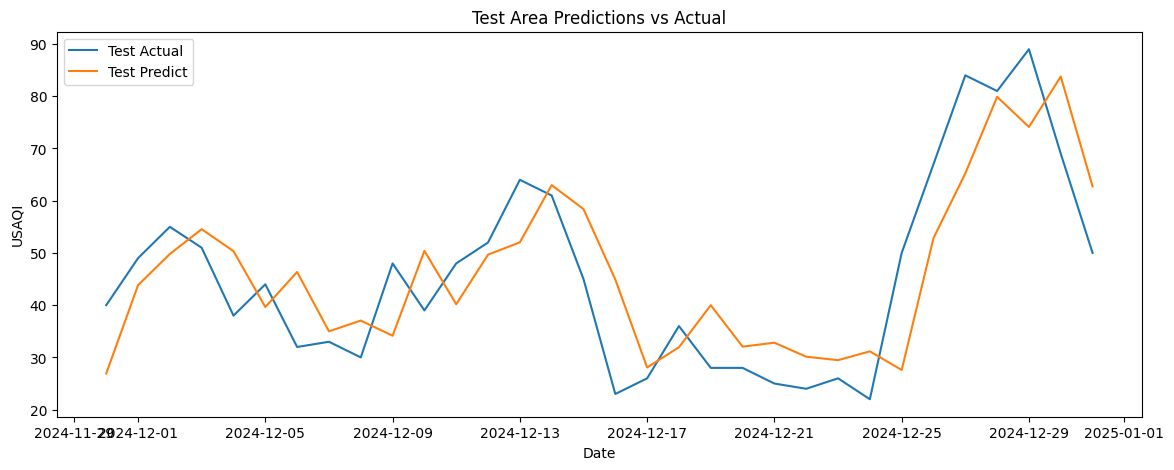

In [6]:
plt.figure(figsize=(14, 5))
plt.plot(test_df['Date'][seq_length:], y_test, label='Test Actual')
plt.plot(test_df['Date'][seq_length:], test_predict, label='Test Predict')
plt.xlabel('Date')
plt.ylabel('USAQI')
plt.legend()
plt.title('Test Area Predictions vs Actual')
plt.show()

In [7]:
# Calculate RMSE for train and test
train_rmse = np.sqrt(mean_squared_error(y_train, train_predict))
test_rmse = np.sqrt(mean_squared_error(y_test, test_predict))

# Calculate MAE for train and test
train_mae = mean_absolute_error(y_train, train_predict)
test_mae = mean_absolute_error(y_test, test_predict)

print(f'Train RMSE: {train_rmse}')
print(f'Test RMSE: {test_rmse}')
print(f'Train MAE: {train_mae}')
print(f'Test MAE: {test_mae}')

Train RMSE: 11.249563411619024
Test RMSE: 11.036932846874285
Train MAE: 8.624984721370904
Test MAE: 9.356382429599762


In [8]:
# Calculate R-squared for train and test
train_r2 = r2_score(y_train, train_predict)
test_r2 = r2_score(y_test, test_predict)

print(f'Train R-squared: {train_r2}')
print(f'Test R-squared: {test_r2}')

Train R-squared: 0.6540994460308547
Test R-squared: 0.6313546535377079


Try with seasonality - use cosine similarity method